In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the Excel file
file_path = "EmoCon_treatment_final_subjects_with_BIDS_cleaned.xlsx"
df = pd.read_excel(file_path)
df.head()

,EmoCon Pseudonym,When was the last time you felt okay?,When was the first time you seeked for help?,Have you been a patient on a psychatric ward before?,How many times on a psychiatric ward?,Bids-Number
0,EmoCon061,childhood,0.5 years ago,yes,2,Sub-039
1,EmoCon063,16 years ago,12 years ago,no,1,Sub-044
2,EmoCon049,4 years ago,2 years ago,yes,2,Sub-036
3,EmoCon052,never,6 years ago,NaN,1,Sub-037
4,EmoCon057,3 years ago,13 years ago,no,1,Sub-038


In [ ]:
# Define final list of used BIDS subjects (EEG + fMRI combined, unique values only)
final_used_subjects = {
    'Sub-007','sub-008','sub-009','sub-012','sub-026','sub-035','sub-036','sub-037','sub-038','sub-039','sub-040','sub-044',
    'Sub-048','sub-049','sub-064','sub-065','sub-066','sub-067','sub-072','sub-075','sub-076','sub-077','sub-081','sub-082',
    'Sub-084','sub-087','sub-092','sub-095','sub-097','sub-098','sub-099','sub-100','sub-102','sub-104','sub-106','sub-107',
    'Sub-108','sub-109','sub-110','sub-111','sub-112','sub-113','sub-114','sub-115','sub-116','sub-117','sub-118','sub-120',
    'Sub-121','sub-122','sub-124','sub-128','sub-129','sub-130','sub-131'
}
# Filter to only those subjects you used
final_df = df[df["Bids-Number"].str.lower().isin(final_used_subjects)]

# Export the filtered dataframe
final_output_path = "/Users/julia/Library/CloudStorage/OneDrive-UniklinikRWTHAachen/Study_EmoCon/EmoCon_treatment_final_subjects.xlsx"
final_df.to_excel(final_output_path, index=False)
final_df.head()


,EmoCon Pseudonym,When was the last time you felt okay?,When was the first time you seeked for help?,Have you been a patient on a psychatric ward before?,How many times on a psychiatric ward?,Bids-Number
0,EmoCon061,childhood,0.5 years ago,yes,2,Sub-039
1,EmoCon063,16 years ago,12 years ago,no,1,Sub-044
2,EmoCon049,4 years ago,2 years ago,yes,2,Sub-036
3,EmoCon052,never,6 years ago,NaN,1,Sub-037
4,EmoCon057,3 years ago,13 years ago,no,1,Sub-038


In [29]:

# Generate descriptive statistics (value counts for categorical data)
final_summary_stats = {}
for col in final_df.columns:
    if final_df[col].dtype == "object":
        final_summary_stats[col] = final_df[col].value_counts(dropna=False)
    else:
        final_summary_stats[col] = final_df[col].describe()
final_summary_stats

{'EmoCon Pseudonym': EmoCon Pseudonym
 EmoCon061    1
 EmoCon165    1
 EmoCon074    1
 EmoCon133    1
 EmoCon134    1
 EmoCon135    1
 EmoCon145    1
 EmoCon151    1
 EmoCon152    1
 EmoCon156    1
 EmoCon146    1
 EmoCon148    1
 EmoCon157    1
 EmoCon063    1
 EmoCon158    1
 EmoCon169    1
 EmoCon174    1
 EmoCon175    1
 EmoCon162    1
 EmoCon163    1
 EmoCon166    1
 EmoCon167    1
 EmoCon178    1
 EmoCon182    1
 EmoCon089    1
 EmoCon091    1
 EmoCon092    1
 EmoCon090    1
 EmoCon049    1
 EmoCon052    1
 EmoCon057    1
 EmoCon048    1
 EmoCon056    1
 EmoCon039    1
 EmoCon017    1
 EmoCon014    1
 EmoCon015    1
 EmoCon125    1
 EmoCon127    1
 EmoCon128    1
 EmoCon106    1
 EmoCon113    1
 EmoCon112    1
 EmoCon078    1
 EmoCon105    1
 EmoCon104    1
 EmoCon103    1
 EmoCon102    1
 EmoCon088    1
 EmoCon183    1
 Name: count, dtype: int64,
 'When was the last time you felt okay?': When was the last time you felt okay?
 NaN              13
 3 years ago       6
 1 year ago 

   When was the last time you felt okay?  count  \
0                                    NaN     13   
1                            3 years ago      6   
2                             1 year ago      6   
3                                  never      5   
4                            2 years ago      5   
5                            5 years ago      4   
6                            4 years ago      2   
7                           13 years ago      2   
8                              childhood      1   
9                           16 years ago      1   
10                         <0.1 year ago      1   
11                          10 years ago      1   
12                         0.2 years ago      1   
13                         0.5 years ago      1   
14                             4-5 Jahre      1   
15                                   NaN     13   
16                                   NaN      6   
17                                   NaN      5   
18                             

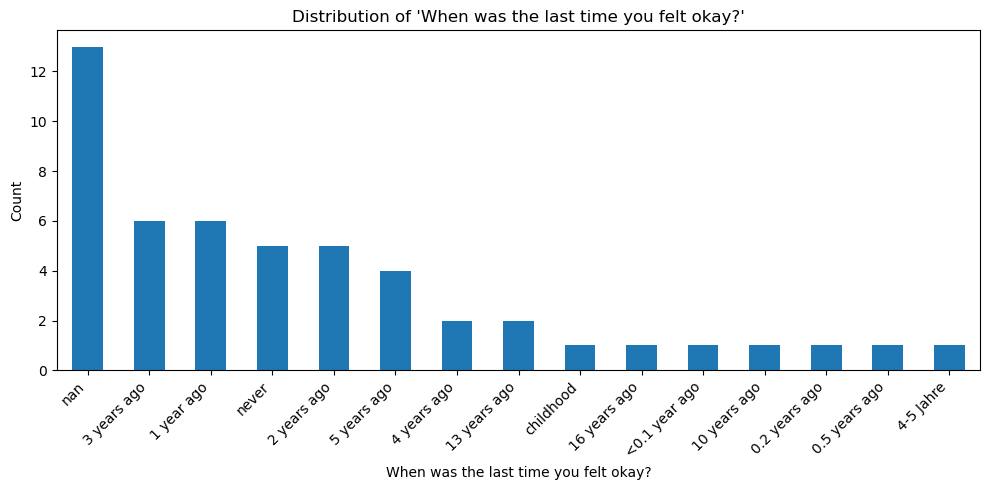

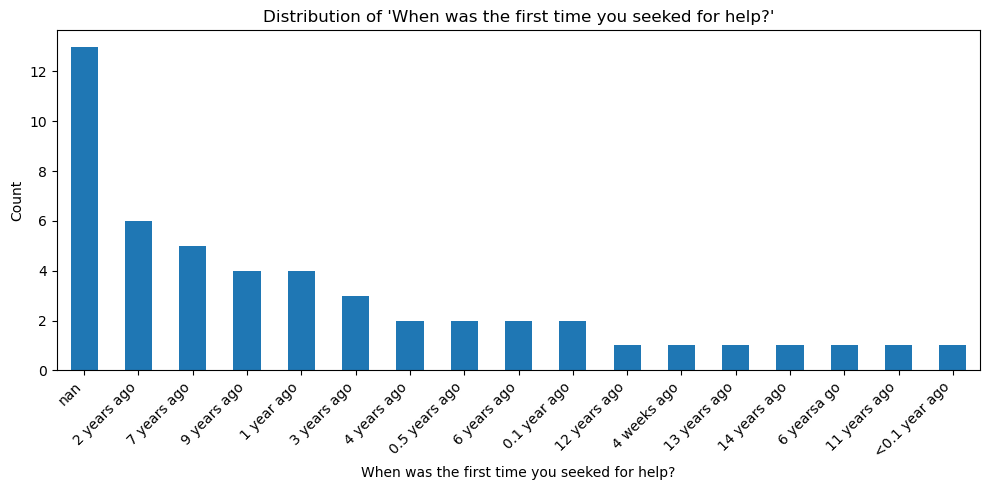

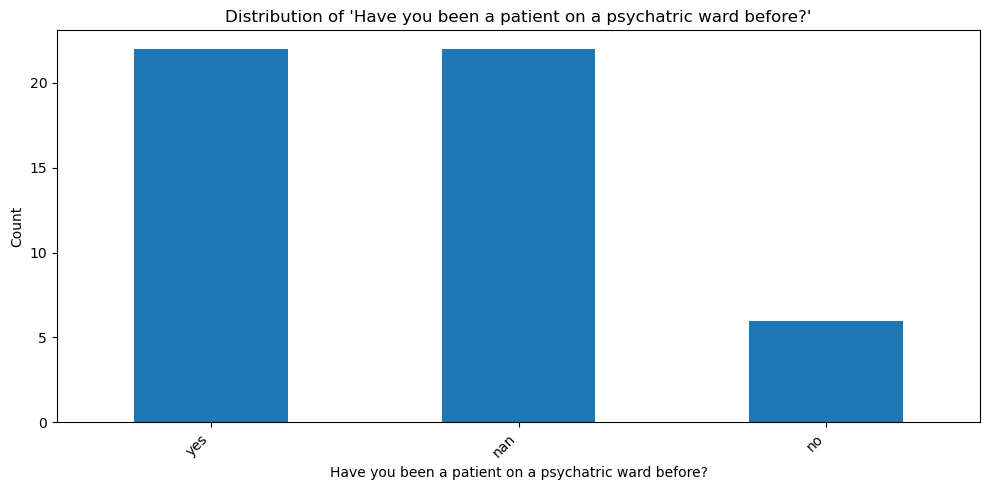

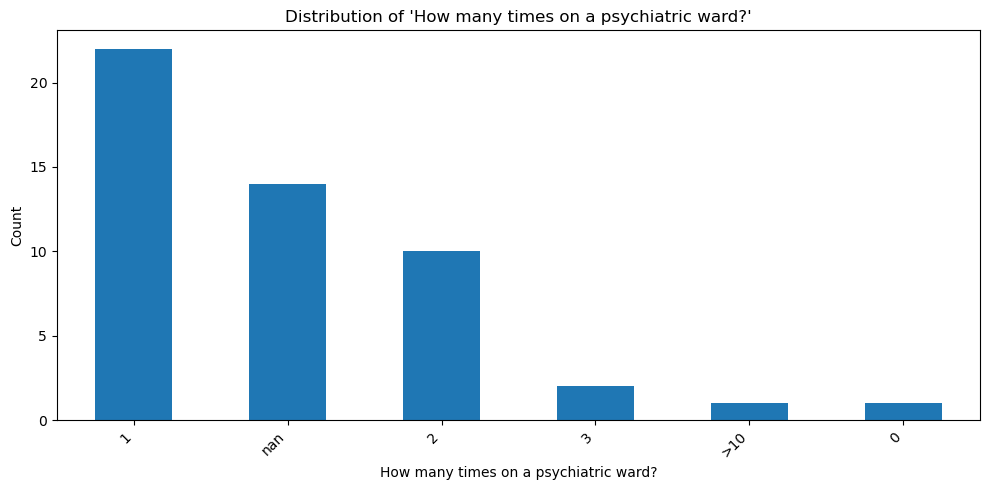

In [33]:
exclude_columns = ["EmoCon Pseudonym", "Bids-Number"]

# === Tabelle mit Häufigkeiten ===
summary_table = pd.DataFrame()

for col in final_df.columns:
    if col not in exclude_columns and final_df[col].dtype == "object":
        counts = final_df[col].value_counts(dropna=False).rename_axis(col).reset_index(name='count')
        counts['column'] = col  # Spaltenname zur Wiedererkennung
        summary_table = pd.concat([summary_table, counts], ignore_index=True)

# Ausgabe der Tabelle (z. B. für Jupyter oder CSV)
summary_table.to_csv("summary_table.csv", index=False)  # Optional: als Datei speichern
print(summary_table)

# === Visualisierung ===
for col in final_df.columns:
    if col not in exclude_columns and final_df[col].dtype == "object":
        plt.figure(figsize=(10, 5))
        final_df[col].value_counts(dropna=False).plot(kind='bar')
        plt.title(f"Distribution of '{col}'")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
